# Data Science with Python Internship – Task 2
## Titanic Dataset: Survival Analysis & Visualization

**Maincrafts Technology**

This notebook loads the Titanic dataset, cleans missing values, answers key survival
questions, and visualizes the results using Seaborn and Matplotlib.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load the Titanic Dataset

The dataset is loaded from `titanic.csv` (the classic Kaggle Titanic dataset, same
schema used by seaborn's built-in copy). Column names are standardized to the
common Kaggle convention (`Survived`, `Pclass`, `Sex`, `Age`, etc.).


In [2]:
df = pd.read_csv("titanic.csv")

# Standardize column names to the familiar Kaggle Titanic convention
df = df.rename(columns={
    "survived": "Survived",
    "pclass": "Pclass",
    "sex": "Sex",
    "age": "Age",
    "sibsp": "SibSp",
    "parch": "Parch",
    "fare": "Fare",
    "embarked": "Embarked",
    "class": "Class",
    "who": "Who",
    "adult_male": "Adult_Male",
    "deck": "Deck",
    "embark_town": "Embark_Town",
    "alive": "Alive",
    "alone": "Alone",
})

print("Shape:", df.shape)
df.head()


Shape: (891, 15)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Class,Who,Adult_Male,Deck,Embark_Town,Alive,Alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Sex          891 non-null    str    
 3   Age          714 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
 7   Embarked     889 non-null    str    
 8   Class        891 non-null    str    
 9   Who          891 non-null    str    
 10  Adult_Male   891 non-null    bool   
 11  Deck         203 non-null    str    
 12  Embark_Town  889 non-null    str    
 13  Alive        891 non-null    str    
 14  Alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


## 3. Data Cleaning

Check for missing values, then handle them.

In [4]:
df.isnull().sum().sort_values(ascending=False)


Deck           688
Age            177
Embarked         2
Embark_Town      2
Sex              0
Pclass           0
Survived         0
Fare             0
Parch            0
SibSp            0
Class            0
Adult_Male       0
Who              0
Alive            0
Alone            0
dtype: int64

In [5]:
# Age: fill missing values with the median age (robust to outliers)
median_age = df["Age"].median()
df["Age"] = df["Age"].fillna(median_age)

# Embarked: fill the (very few) missing values with the mode (most common port)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Deck has too many missing values (~77%) to impute meaningfully — drop the column
df = df.drop(columns=["Deck"])

# Confirm no critical missing values remain
df.isnull().sum().sort_values(ascending=False)


Embark_Town    2
Survived       0
Sex            0
Age            0
SibSp          0
Pclass         0
Parch          0
Fare           0
Class          0
Embarked       0
Who            0
Adult_Male     0
Alive          0
Alone          0
dtype: int64

We also create an **Age Group** column so we can analyze survival rate by
life stage (Child, Teen, Adult, Senior).


In [6]:
bins = [0, 12, 19, 59, 100]
labels = ["Child (0-12)", "Teen (13-19)", "Adult (20-59)", "Senior (60+)"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)
df[["Age", "AgeGroup"]].head()


,Age,AgeGroup
0,22.0,Adult (20-59)
1,38.0,Adult (20-59)
2,26.0,Adult (20-59)
3,35.0,Adult (20-59)
4,35.0,Adult (20-59)


## 4. Analysis Questions

### Q1: Who survived more — males or females?


In [7]:
survival_by_gender = df.groupby("Sex")["Survived"].mean() * 100
print(survival_by_gender.round(2))

print(f"\nFemale survival rate: {survival_by_gender['female']:.1f}%")
print(f"Male survival rate:   {survival_by_gender['male']:.1f}%")


Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

Female survival rate: 74.2%
Male survival rate:   18.9%


**Insight:** Females survived at a much higher rate than males — a reflection
of the "women and children first" evacuation priority during the disaster.


### Q2: Did passenger class affect survival chances?

In [8]:
survival_by_class = df.groupby("Pclass")["Survived"].mean() * 100
print(survival_by_class.round(2))


Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


**Insight:** 1st class passengers had the highest survival rate, followed by
2nd class, with 3rd class passengers surviving least often — likely due to cabin
location, proximity to lifeboats, and boarding priority.


### Q3: What was the survival rate by age group?

In [9]:
survival_by_age = df.groupby("AgeGroup", observed=True)["Survived"].mean() * 100
print(survival_by_age.round(2))


AgeGroup
Child (0-12)     57.97
Teen (13-19)     41.05
Adult (20-59)    36.52
Senior (60+)     26.92
Name: Survived, dtype: float64


**Insight:** Children had the highest survival rate among age groups,
consistent with the evacuation priority given to children, while adults and
seniors survived at lower rates.


## 5. Visualizations

### 5.1 Survival by Gender


/tmp/ipykernel_126/1785004958.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex", y="Survived", data=df, palette="Set2")


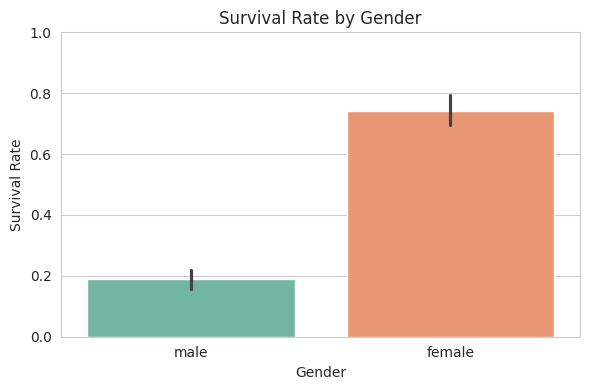

In [10]:
plt.figure(figsize=(6, 4))
sns.barplot(x="Sex", y="Survived", data=df, palette="Set2")
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.xlabel("Gender")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("survival_by_gender.png", dpi=150)
plt.show()


### 5.2 Survival by Passenger Class

/tmp/ipykernel_126/3433879570.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Pclass", y="Survived", data=df, palette="Set2")


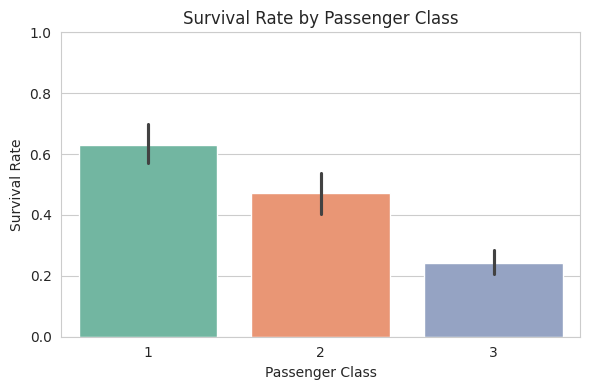

In [11]:
plt.figure(figsize=(6, 4))
sns.barplot(x="Pclass", y="Survived", data=df, palette="Set2")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("survival_by_class.png", dpi=150)
plt.show()


### 5.3 Histogram of Passenger Ages

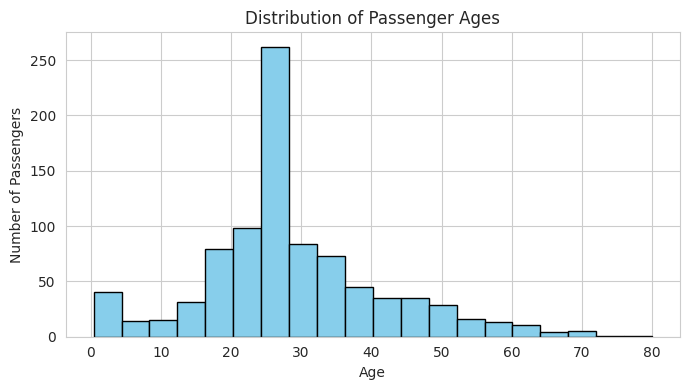

In [12]:
plt.figure(figsize=(7, 4))
df["Age"].plot(kind="hist", bins=20, edgecolor="black", color="skyblue")
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.savefig("age_histogram.png", dpi=150)
plt.show()


### 5.4 Bonus: Survival Rate by Age Group

/tmp/ipykernel_126/2521061650.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="AgeGroup", y="Survived", data=df, order=labels, palette="Set2")


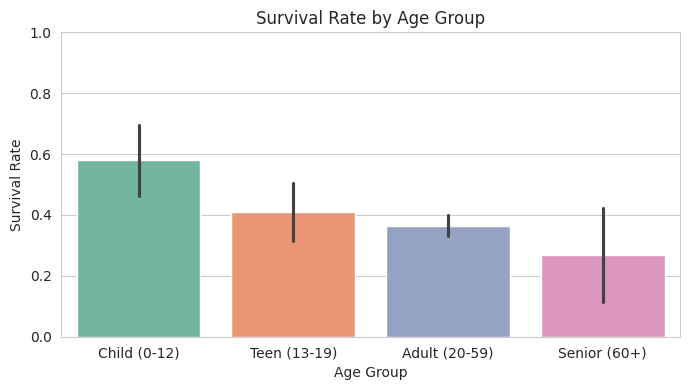

In [13]:
plt.figure(figsize=(7, 4))
sns.barplot(x="AgeGroup", y="Survived", data=df, order=labels, palette="Set2")
plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Rate")
plt.xlabel("Age Group")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("survival_by_agegroup.png", dpi=150)
plt.show()


## 6. Summary of Insights

- **Gender:** Women survived at a far higher rate than men (~74% vs ~19%),
  reflecting the "women and children first" evacuation policy.
- **Passenger Class:** Survival chances dropped from 1st to 3rd class, showing
  that socioeconomic status and cabin location strongly influenced survival.
- **Age Group:** Children had the best survival odds of any age group, while
  adults and seniors fared worse — again consistent with evacuation priorities.
- **Overall:** The Titanic disaster's survival pattern was shaped heavily by
  social factors (gender, class) rather than random chance.
